# Density Based Approach

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from collections import Counter
from collections import defaultdict
from sklearn.preprocessing import StandardScaler

In [4]:
#df = pd.read_csv('../dataset/cmi_internet_imputed.csv')
df = pd.read_csv('cmi_internet_imputed.csv')
df

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time,sii
0,5.0,0.0,51,46.000000,50.8,26.000000,69,5,87,114,...,1,24.434900,8.895360,38.917700,19.541300,2.12927,60,3,448,2.0
1,9.0,0.0,66,48.000000,46.0,22.000000,75,5,70,122,...,1,21.035200,14.974000,39.449700,15.410700,2.01000,64,0,434,0.0
2,10.0,1.0,71,56.500000,75.6,26.003679,65,5,94,117,...,2,30.424101,32.959842,56.996400,33.418724,2.17000,54,2,453,0.0
3,9.0,0.0,71,56.000000,81.6,26.000000,60,6,97,117,...,2,30.404100,16.779000,58.933800,26.479800,2.45100,45,0,577,1.0
4,18.0,1.0,65,62.206792,77.0,26.000000,68,5,80,116,...,2,28.855800,23.975607,56.996400,33.915114,1.04000,58,1,433,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,7.0,1.0,69,46.070000,49.0,22.250000,58,2,82,103,...,1,21.134424,12.375831,37.154343,16.637908,3.00000,55,0,510,0.0
8456,10.0,1.0,70,56.130000,47.8,28.500000,66,5,80,108,...,1,22.690881,16.569017,48.610678,22.983200,2.00000,57,0,452,1.0
8457,10.0,1.0,70,49.560000,47.2,25.341680,64,7,84,120,...,2,30.581230,32.655921,50.805915,31.594712,2.00000,57,2,528,0.0
8458,15.0,1.0,56,63.790000,99.5,31.100000,67,5,88,108,...,2,30.387635,25.248149,84.622873,46.467581,2.00000,59,1,478,2.0


In [5]:
X = df.drop(columns=['sii'])
y = df['sii']

num_cols = X.select_dtypes(include=np.number).columns.tolist()
print("Variables used:")
print(num_cols)
print("Shape:", X.shape)

Variables used:
['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Fitness_Endurance-Max_Stage', 'Physical-HeartRate', 'Physical-Systolic_BP', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'FGC-FGC_SRL', 'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_DEE', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMR', 'BIA-BIA_ECW', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'PAQ_Total', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'Fitness_Endurance-Time']
Shape: (8460, 32)


In [6]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

X = pd.DataFrame(
    X,
    columns=num_cols,
    index=df.index
)

X

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Fitness_Endurance-Max_Stage,Physical-HeartRate,Physical-Systolic_BP,...,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,PAQ_Total,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,Fitness_Endurance-Time
0,-1.466005,-0.820524,-0.498029,-1.557387,-0.864862,-0.281208,0.008791,0.102306,0.474905,-0.122860,...,-0.642638,-1.376198,-0.146057,-0.145012,-0.237738,-0.190245,-0.180229,0.200805,1.985105,0.088725
1,-0.346958,-0.820524,-0.031912,-1.278690,-0.987775,-1.456603,0.575074,0.102306,-1.100008,0.476259,...,-0.919715,-1.376198,-0.212004,-0.090573,-0.233311,-0.241430,-0.402756,0.617230,-0.969503,-0.073011
2,-0.067196,1.218734,0.123460,-0.094229,-0.229815,-0.280127,-0.368731,0.102306,1.123399,0.101810,...,-0.274774,0.442964,-0.029880,0.070505,-0.087305,-0.018283,-0.104238,-0.423833,1.000236,0.146488
3,-0.346958,-0.820524,0.123460,-0.163903,-0.076175,-0.281208,-0.840633,1.091463,1.401325,0.101810,...,-0.134744,0.442964,-0.030268,-0.074408,-0.071184,-0.104267,0.420034,-1.360791,-0.969503,1.579007
4,2.170899,1.218734,-0.062986,0.701003,-0.193966,-0.281208,-0.085589,0.102306,-0.173589,0.026920,...,-0.274774,0.442964,-0.060302,-0.009956,-0.087305,-0.012132,-2.212521,-0.007408,0.015367,-0.084563
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,-0.906481,1.218734,0.061311,-1.547632,-0.910954,-1.383141,-1.029394,-2.865163,0.011695,-0.946650,...,-0.961828,-1.376198,-0.210079,-0.113842,-0.252411,-0.226223,1.444323,-0.319727,-0.969503,0.804985
8456,-0.067196,1.218734,0.092386,-0.145788,-0.941683,0.453414,-0.274350,0.102306,-0.173589,-0.572200,...,-0.725216,-1.376198,-0.179888,-0.076288,-0.157083,-0.147595,-0.421414,-0.111514,-0.969503,0.134936
8457,-0.067196,1.218734,0.092386,-1.061307,-0.957047,-0.474654,-0.463111,2.080619,0.196979,0.326479,...,-1.129565,0.442964,-0.026832,0.067784,-0.138816,-0.040885,-0.421414,-0.111514,1.000236,1.012931
8458,1.331614,1.218734,-0.342657,0.921620,0.382186,1.217421,-0.179970,0.102306,0.567547,-0.572200,...,0.282455,0.442964,-0.030588,0.001441,0.142574,0.143412,-0.421414,0.096698,0.015367,0.435303


## LOF (sklearn)

In [7]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, _, _ = train_test_split(X, y, test_size=0.3, random_state=0)

In [ ]:
#outlof = LocalOutlierFactor(n_neighbors=2, novelty=True)
#outlof.fit(X_train)
#y_pred = outlof.predict(X_test)

,"n_neighbors n_neighbors: int, default=20Number of neighbors to use by default for :meth:`kneighbors` queries.If n_neighbors is larger than the number of samples provided,all samples will be used.",3
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf is size passed to :class:`BallTree` or :class:`KDTree`. This canaffect the speed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:func:`sklearn.metrics.pairwise_distances`. When p = 1, thisis equivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. When fitting this is used to define thethreshold on the scores of the samples.- if 'auto', the threshold is determined as in the original paper,- if a float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"novelty novelty: bool, default=FalseBy default, LocalOutlierFactor is only meant to be used for outlierdetection (novelty=False). Set novelty to True if you want to useLocalOutlierFactor for novelty detection. In this case be aware thatyou should only use predict, decision_function and score_sampleson new unseen data and not on the training set; and note that theresults obtained this way may differ from the standard LOF results... versionadded:: 0.20",True
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [ ]:
outlof2 = LocalOutlierFactor(n_neighbors=2) #, novelty=True
# I have tried 2 neighbours (1244 outliers), 3 (1157), 4 (1158)

In [ ]:
outliers = outlof2.fit_predict(X)

array([ 1,  1, -1, ..., -1,  1,  1], shape=(8460,))

In [57]:
outlof2.negative_outlier_factor_

array([-1.00725156, -1.22235143, -1.41233921, ..., -1.52435505,
       -1.04058989, -1.17673753], shape=(8460,))

In [52]:
print(min(outlof2.negative_outlier_factor_))
print(max(outlof2.negative_outlier_factor_))

-6.367868482350088
-0.9316407095428603


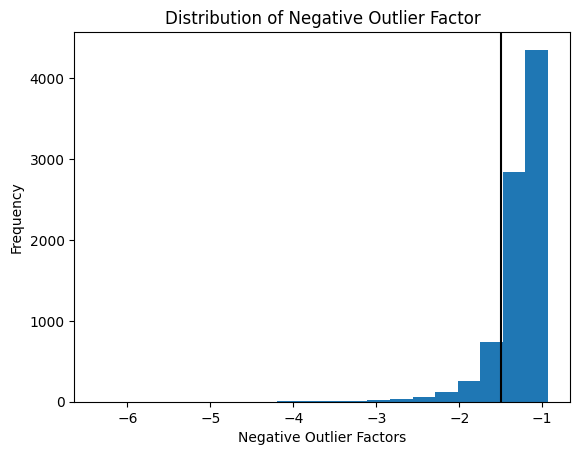

In [53]:
# Plotting the negative outlier factor
# The black vertical line indicates: points to its right are inliers, to its left are outliers.
plt.hist(outlof2.negative_outlier_factor_, bins=20)
plt.axvline(np.min(outlof2.negative_outlier_factor_[np.where(outliers==1)]), c='k')
plt.title('Distribution of Negative Outlier Factor')
plt.xlabel('Negative Outlier Factors')
plt.ylabel('Frequency')
plt.show()

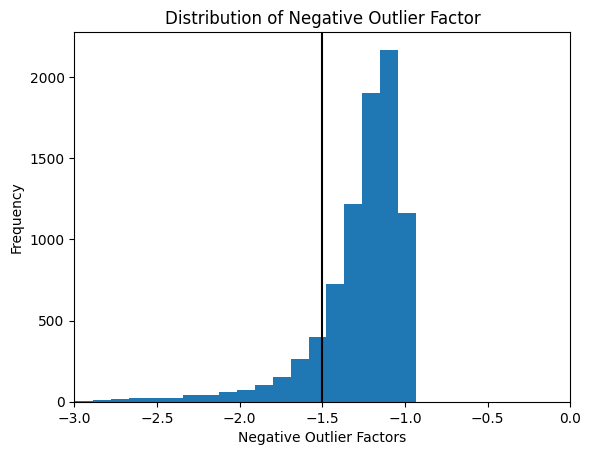

In [54]:
plt.hist(outlof2.negative_outlier_factor_, bins=50)
plt.axvline(np.min(outlof2.negative_outlier_factor_[np.where(outliers==1)]), c='k')
plt.title('Distribution of Negative Outlier Factor')
plt.xlabel('Negative Outlier Factors')
plt.xlim(-3, 0)
plt.ylabel('Frequency')
plt.show()

In [60]:
# Outliers count:
# predict returns 1 for an inlier and -1 for an outlier
np.unique(outliers, return_counts=True)

(array([-1,  1]), array([1244, 7216]))

In [61]:
n_out = abs(outliers[outliers == -1].sum())
perc_out = n_out / len(outliers) * 100

print("Number of LOF outliers:", n_out)
print("Percentage of LOF outliers:", round(perc_out, 3), "%")

Number of LOF outliers: 1244
Percentage of LOF outliers: 14.704 %


## COF

In [39]:
from pyod.models.cof import COF

In [40]:
outcof = COF()
outcof.fit(X)

,contamination,0.1
,n_neighbors,20
,method,'fast'


In [ ]:
outliers = outcof.predict(X)

In [ ]:
outcof.decision_scores_

array([1.03102284, 1.25795566, 2.0111458 , ..., 1.87832529, 1.29769021,
       1.26367457], shape=(8460,))

In [49]:
print(min(outcof.decision_scores_))
print(max(outcof.decision_scores_))

0.881523001105988
3.0774015857321615


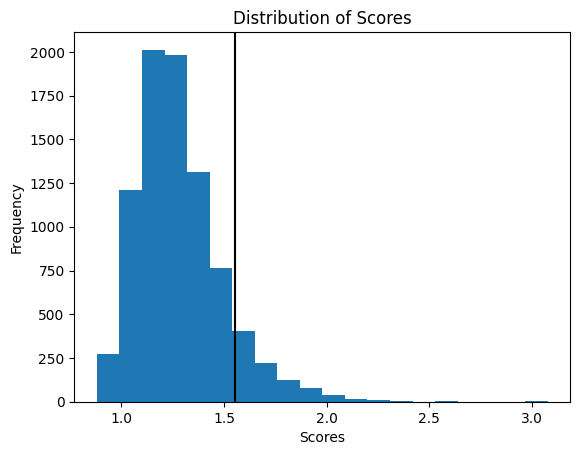

In [45]:
# Plotting the decision scores
# The black vertical line indicates: points to its right are inliers, to its left are outliers.
plt.hist(outcof.decision_scores_, bins=20)
plt.axvline(np.min(outcof.decision_scores_[np.where(outliers==1)]), c='k')
plt.title('Distribution of Scores')
plt.xlabel('Scores')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Outliers count:
# predict returns 0 for an inlier and 1 for an outlier
np.unique(outliers, return_counts=True)

In [42]:
n_out = abs(outliers[outliers == 1].sum())
perc_out = n_out / len(outliers) * 100

print("Number of COF outliers:", n_out)
print("Percentage of COF outliers:", round(perc_out, 3), "%")

Number of COF outliers: 846
Percentage of COF outliers: 10.0 %
